## Suivi Par MPOUAVOULI Rayde Prosperin
## Chapitre 3 :Maitriser les moyennes mobiles en finance

### Objectifs pédagogiques

##### Calculer des moyennes mobiles simples (SMA) et exponentielles(EMA) avec pandas
##### Visualiser les tendances à l'aide de matplotlib

In [ ]:
### 1- Importation de la base des données APPLE

In [21]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


In [9]:
apple = yf.download("AAPL", start="2021-01-01", end="2024-12-31")
apple.columns =apple.columns.droplevel("Ticker")
apple

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_58336\1101895203.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download("AAPL", start="2021-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,126.096588,130.189048,123.514437,130.101356,143301900
2021-01-05,127.655624,128.366944,125.141681,125.589909,97664900
2021-01-06,123.358513,127.694579,123.144145,124.449839,155088000
2021-01-07,127.567917,128.259745,124.586268,125.073466,109578200
2021-01-08,128.668991,129.234143,126.895583,129.039251,105158200
...,...,...,...,...,...
2024-12-23,254.367020,254.745665,252.553450,253.868788,40858800
2024-12-24,257.286652,257.296596,254.386927,254.586231,23234700
2024-12-26,258.103729,259.179926,256.718662,257.276679,27237100


### 2- Calculer une moyenne mobile simple(MA)

##### La SMA(simple Moving Average) est la moyenne arithmétique des prix de cloture sur une période donnée. Elle est utile pour lisser les variations de prix et identifier les tendances de fond
#### Conséquence de cette moyenne mobile simple elle accorde la meme pondération à toutes les observations

$$
SMA_t = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}
$$


In [15]:
apple["SMA_20"] = apple["Close"].rolling(window=20).mean()
apple["SMA_10"] = apple["Close"].rolling(window=10).mean()
apple["SMA_20"].head(25)

Date
2021-01-04           NaN
2021-01-05           NaN
2021-01-06           NaN
2021-01-07           NaN
2021-01-08           NaN
2021-01-11           NaN
2021-01-12           NaN
2021-01-13           NaN
2021-01-14           NaN
2021-01-15           NaN
2021-01-19           NaN
2021-01-20           NaN
2021-01-21           NaN
2021-01-22           NaN
2021-01-25           NaN
2021-01-26           NaN
2021-01-27           NaN
2021-01-28           NaN
2021-01-29           NaN
2021-02-01    129.684311
2021-02-02    129.956168
2021-02-03    130.098917
2021-02-04    130.624604
2021-02-05    130.919085
2021-02-08    131.165830
Name: SMA_20, dtype: float64

In [16]:
apple["SMA_10"].head(10)

Date
2021-01-04          NaN
2021-01-05          NaN
2021-01-06          NaN
2021-01-07          NaN
2021-01-08          NaN
2021-01-11          NaN
2021-01-12          NaN
2021-01-13          NaN
2021-01-14          NaN
2021-01-15    126.15602
Name: SMA_10, dtype: float64

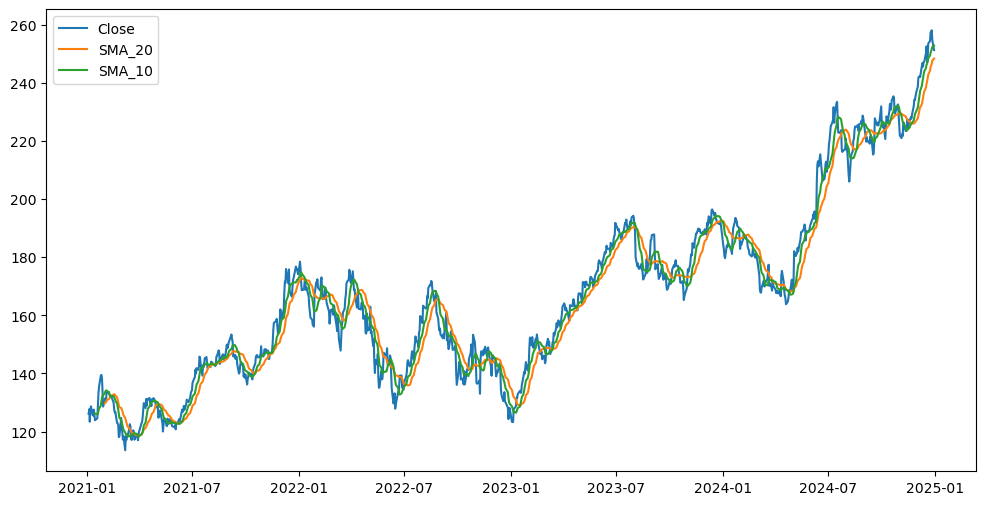

In [34]:
plt.figure(figsize=(12,6))
plt.plot(apple["Close"], label ="Close")
plt.plot(apple["SMA_20"], label ="SMA_20")
plt.plot(apple["SMA_10"], label ="SMA_10")
plt.legend()
plt.show()

### 3- Clculer une moyenne mobile exponentielle (EMA)

#### l'EMA(exponential moving Average) donne plus de poids au prix récents. Elle réagit plus rapidement aux changements de tendance que la SMA

In [31]:
apple["EMA"]= apple["Close"].ewm(alpha=0.55).mean()
apple.head(25)

Price,Close,High,Low,Open,Volume,SMA_20,SMA_10,EMA
Date,,,,,,,,
2021-01-04,126.096588,130.189048,123.514437,130.101356,143301900,NaN,NaN,126.096588
2021-01-05,127.655624,128.366944,125.141681,125.589909,97664900,NaN,NaN,127.171786
2021-01-06,123.358513,127.694579,123.144145,124.449839,155088000,NaN,NaN,124.864208
2021-01-07,127.567917,128.259745,124.586268,125.073466,109578200,NaN,NaN,126.414833
2021-01-08,128.668991,129.234143,126.895583,129.039251,105158200,NaN,NaN,127.677928
2021-01-11,125.677597,126.837131,125.209891,125.882227,100384500,NaN,NaN,126.568534
2021-01-12,125.502197,126.369409,123.611867,125.209876,91951100,NaN,NaN,125.979849
2021-01-13,127.538689,128.084348,125.200144,125.463220,88636800,NaN,NaN,126.838655
2021-01-14,125.609383,127.645867,125.463214,127.450990,90221800,NaN,NaN,126.162043


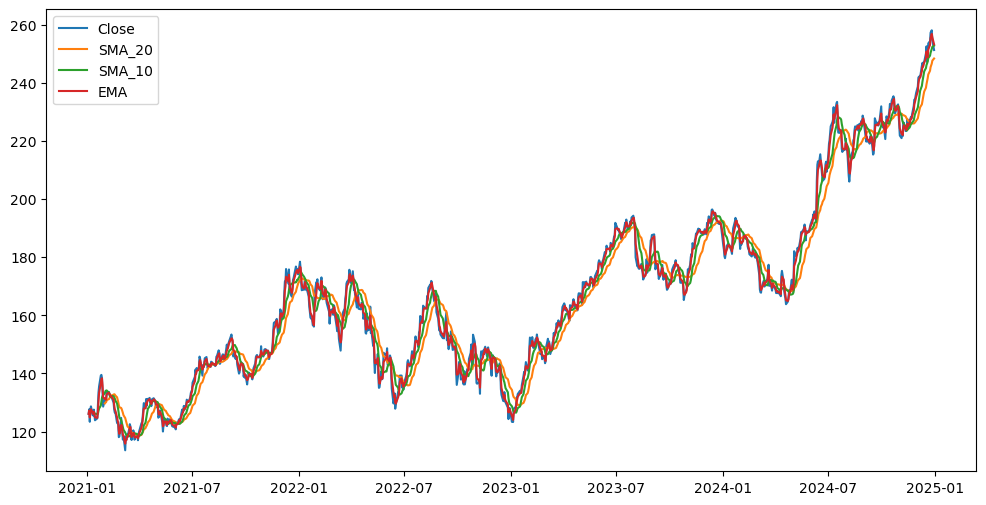

In [35]:
plt.figure(figsize=(12,6))
plt.plot(apple["Close"], label ="Close")
plt.plot(apple["SMA_20"], label ="SMA_20")
plt.plot(apple["SMA_10"], label ="SMA_10")
plt.plot(apple["EMA"], label ="EMA")
plt.legend()
plt.show()
